Importando Biblioteca

In [1]:
# Bibliotecas essenciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from pathlib import Path
import os
import gc

# Para Deep Learning
import tensorflow as tf
from tensorflow import keras
import tensorflow_hub as hub
import tensorflow_datasets as tfds

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
									MaxPooling2D,
                                    GlobalMaxPooling2D,
									Flatten,
									Dense,
									Dropout,
									Conv2D,
									BatchNormalization,
                                    Activation  
								)

from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint)
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.utils import to_categorical

# Ajuste fino com aumento de dados (Data Augmentation)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.datasets import cifar10

# Para validação do modelo
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn import model_selection
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split

import pickle

In [2]:
def unpickle(file):
    
    with open(file, 'rb') as fo:
        data = pickle.load(
            fo,
            encoding='bytes'
        )

    return data

In [3]:
base_dir = "./cifar-10-python"

base_files = [
    "data_batch_1",
    "data_batch_2",
    "data_batch_3",
    "data_batch_4",
    "data_batch_5"
]


X_base = []
y_base = []


for file in base_files:

    caminho = os.path.join(
        base_dir,
        file
    )

    batch = unpickle(caminho)

    X_base.append(
        batch[b'data']
    )

    y_base.extend(
        batch[b'labels']
    )

In [4]:
batch[b'data'].shape

(10000, 3072)

In [5]:
meta_path = os.path.join(base_dir, "batches.meta")

meta = unpickle(meta_path)

category_names = [
    nome.decode('utf-8')
    for nome in meta[b'label_names']
]

category_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

Treinando Dados

In [6]:
X_base = np.concatenate(
    X_base,
    axis=0
)

y_base = np.array(y_base)

In [7]:
X_base.shape

(50000, 3072)

In [8]:
y_base.shape

(50000,)

In [9]:
X_base = X_base.reshape(
    -1,
    3,
    32,
    32
)

In [10]:
X_base.shape

(50000, 3, 32, 32)

In [11]:
X_base = np.transpose(
    X_base,
    (0,2,3,1)
)

In [12]:
X_base.shape

(50000, 32, 32, 3)

In [13]:
X_base = X_base.astype('float32') / 255.0

In [14]:
X_base.shape

(50000, 32, 32, 3)

In [15]:
y_base.shape

(50000,)

Construindo um dataframe

In [16]:
num_classes = len(np.unique(y_base))

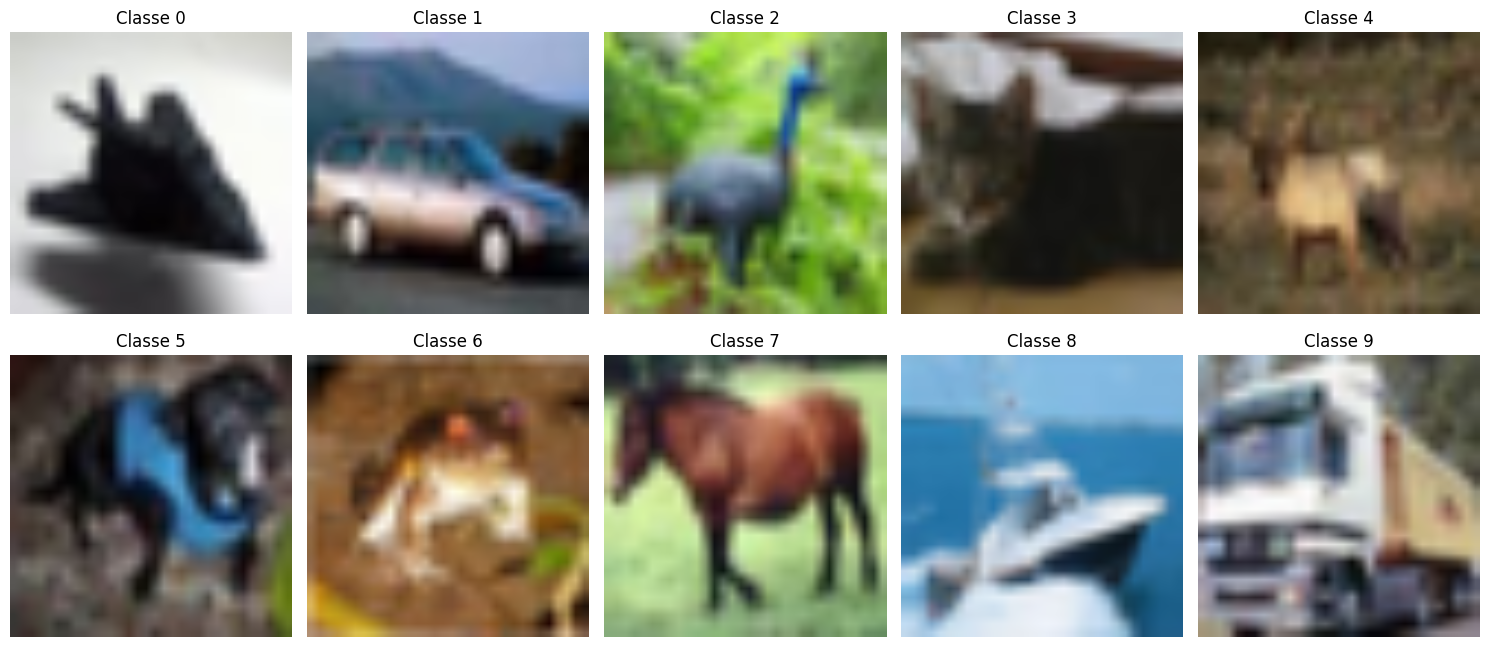

In [17]:
# Configura o número de linhas e colunas para visualizar os dados no plot
ROW = 2
COLUMN = 5

# Dimensões da figura
plt.figure(figsize=(15, 7))

# Loop para cada classe
for i in range(num_classes):
    # Obtém o caminho da imagem
    image = X_base[np.where(y_base == i)[0][0]]

    # Define a posição da imagem no grid
    plt.subplot(ROW, COLUMN, i + 1)

    # Carrega e mostra a imagem
    plt.imshow(image, interpolation='bilinear')

    # Adiciona o nome da classe
    plt.title(f'Classe {i}')

    # Remove os eixos
    plt.axis('off')

    # Ajusta espaçamento
    plt.tight_layout()

plt.show()

In [18]:
# Tamanho das imagens no CIFAR10
image_size = 32

# Define a forma de entrada das imagens passadas pelo modelo
input_shape = (image_size, image_size, 3)

# Defina a taxa de aprendizado e a queda de peso para o otimizador usar
learning_rate = 0.001

# Defindo uma semente aleatória para utilizar sempre os mesmos dados durante nossos testes
rand_seed = 42
tf.random.set_seed(rand_seed) 

# Define o numero de epocas de treinamento global
training_epochs = 20


## Separando em treino e teste a base de dados

Agora com as imagens e classes organizadas, podemos aplicar o train_test_split para separar as bases de treinamento e teste:

In [19]:
# Diminuindo o tamanho da base para rodar localmente

X_base, _, y_base, _ = train_test_split(
    X_base,
    y_base,
    train_size=10000,
    random_state=rand_seed,
    stratify=y_base
)

In [20]:
X_base.shape

(10000, 32, 32, 3)

In [21]:
x_train, x_test, y_train, y_test = train_test_split(X_base,y_base, test_size=0.3, stratify=y_base, random_state=rand_seed)


In [22]:
# Analisando a dimensão dos dados
x_train.shape

(7000, 32, 32, 3)

In [23]:
x_test.shape

(3000, 32, 32, 3)

In [24]:
# # Achatar os dados de teste e treinamento
# x_train_flat = x_train.reshape(x_train.shape[0], x_train.shape[1]* x_train.shape[2]* x_train.shape[3])
# x_test_flat = x_test.reshape(x_test.shape[0], x_test.shape[1] * x_test.shape[2] * x_test.shape[3])

In [25]:
# # Visualizando a transformação
# x_train_flat.shape

In [26]:
# Converte um vetor de classe (inteiros) em uma matriz de classe categórica.
y_train_tf = keras.utils.to_categorical(y_train, num_classes)
y_test_tf = keras.utils.to_categorical(y_test, num_classes)

 Vamos configurar agora como próximo passo o ModelCheckpoint para usar os melhores pesos para este modelo. Um dos benefícios do ModelCheckpoint é salvar uma cópia do modelo em disco em intervalos regulares (como após cada época de processamento) para que você possa retomar o treinamento a partir do ponto em que parou, minimizando perdas de tempo e recursos computacionais.

In [27]:
# Defina um objeto ModelCheckpoint para usar os melhores pesos para este modelo
checkpointer = ModelCheckpoint(filepath="cnn_weights.best.keras", verbose=0, save_best_only=True) # save best model

Treinando a CNN

In [28]:
model = Sequential() # Abrindo a sequencia do modelo

model.add(Input(shape=input_shape)) # primeira camada explicita

# 1 camada convolucional com 128 neurônios | filtro utilizando uma matriz 3x3 sendo movimentado por um stride de 2
# padding ativado (com bordas de zeros) | função de ativação ReLU | regularização L2 ativada
model.add(Conv2D(128,
                 kernel_size=(3, 3),
                 strides=(2, 2),
                 padding='same',
                 activation='relu',
                 kernel_regularizer=keras.regularizers.l2(0.001)))

# Camada de MaxPolling ativada, com uma matriz 2x2. Padding ativado
model.add(MaxPooling2D(pool_size=(2, 2), strides=None, padding='same'))

# Regularização de dropout ativada
model.add(Dropout(0.2))

# 2 camada convolucional com 92 neurônios | filtro utilizando uma matriz 3x3 sendo movimentado por um stride de 2
# padding ativado (com bordas de zeros) | função de ativação ReLU | regularização L2 ativada
model.add(Conv2D(92,
                 kernel_size=(3, 3),
                 strides=(2, 2),
                 padding='same',
                 activation='relu',
                 kernel_regularizer=keras.regularizers.l2(0.001)))

# Camada de MaxPolling ativada, com uma matriz 2x2. Padding ativado
model.add(MaxPooling2D(pool_size=(2, 2), strides=None, padding='same'))

# Regularização de dropout ativada
model.add(Dropout(0.2))

# Camada que achata dos dados da imagem
model.add(Flatten())
# Camada Densa da rede neural convolucional + função de ativação ReLU
model.add(Dense(256, activation='relu'))
# Camada de saída da rede, utilizando a função de ativação softmax
model.add(Dense(y_train_tf.shape[1], activation='softmax'))

In [29]:
# Monitor para interromper o modelo antecipadamente quando a melhoria da perda de validação for mínima
monitor = EarlyStopping(monitor='val_loss', min_delta=1e-5, patience=10, verbose=1, mode='auto')

# Compilando o modelo e aplicação a função de custo Adam (utilizando a learning rate que configuramos anteriormente)
model.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate), metrics=['accuracy'])

# Salve os dados do modelo em um arquivo keras
model.save('./modeloAtividade1.keras')
# Resumo do modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 92)       │       106,076 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 92)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 2, 92)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 368)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        94,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,694 (807.40 KB)

 Trainable params: 206,694 (807.40 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Treinando o modelo
history = model.fit(x_train,y_train_tf, validation_split=0.25, callbacks=[monitor,checkpointer],
                    verbose=1, epochs=training_epochs, batch_size=32, shuffle=True)

Epoch 1/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1574 - loss: 2.2947 - val_accuracy: 0.3200 - val_loss: 1.9761
Epoch 2/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3075 - loss: 1.9182 - val_accuracy: 0.3600 - val_loss: 1.8218
Epoch 3/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3566 - loss: 1.8001 - val_accuracy: 0.3926 - val_loss: 1.7277
Epoch 4/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3915 - loss: 1.7157 - val_accuracy: 0.4160 - val_loss: 1.6539
Epoch 5/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4231 - loss: 1.6237 - val_accuracy: 0.4629 - val_loss: 1.5697
Epoch 6/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4648 - loss: 1.5441 - val_accuracy: 0.4829 - val_loss: 1.5256
Epoch 7/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4867 - loss: 1.4720 - val_accuracy: 0.4771 - val_loss: 1.5437
Epoch 8/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5052 - loss: 1.4333 - val_accuracy: 0.

Validação do Modelo

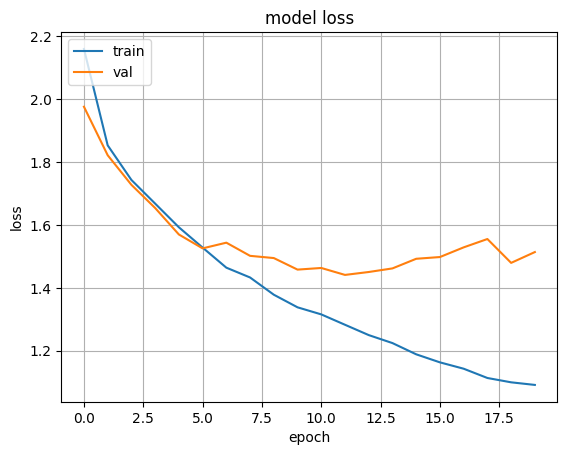

In [31]:
# Validação o erro por épocas
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

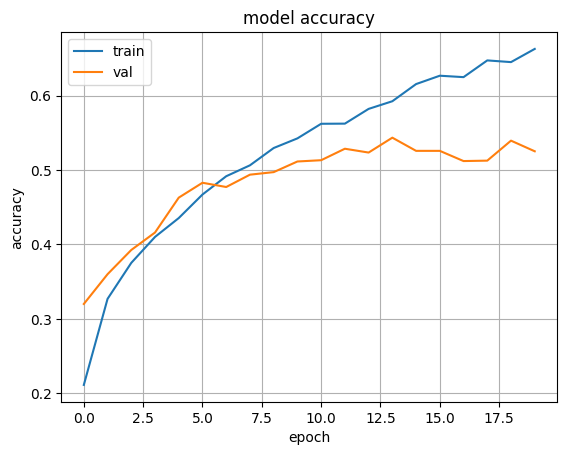

In [32]:
# Validação da acurácia por épocas
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

In [33]:
# Armazena as predicações do modelo dos dados de teste
cnn_pred = model.predict(x_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [34]:
# Define o índice do valor máximo do modelo de previsão para uma variável
# O valor máximo indica o caractere de previsão do modelo que a imagem representa
cnn_pred = np.argmax(cnn_pred,axis=1)

# Define uma variável para armazenar o rótulo que representa o resultado verdadeiro
y_true = np.argmax(y_test_tf,axis=1)

In [35]:
# Criando a matriz de confusão
cnn_cm = metrics.confusion_matrix(y_true, cnn_pred)
# Definindo a acurácia
cnn_accuracy = metrics.accuracy_score(y_true, cnn_pred)

# Print do classification report
print(metrics.classification_report(y_true, cnn_pred, target_names=category_names))
# Print da acurácia
print("Accuracy score: {}".format(cnn_accuracy))

              precision    recall  f1-score   support

    airplane       0.69      0.64      0.66       300
  automobile       0.70      0.58      0.64       300
        bird       0.48      0.36      0.41       300
         cat       0.34      0.33      0.34       300
        deer       0.43      0.50      0.46       300
         dog       0.38      0.59      0.47       300
        frog       0.60      0.59      0.59       300
       horse       0.65      0.55      0.59       300
        ship       0.72      0.69      0.70       300
       truck       0.63      0.64      0.63       300

    accuracy                           0.55      3000
   macro avg       0.56      0.55      0.55      3000
weighted avg       0.56      0.55      0.55      3000

Accuracy score: 0.547


In [36]:
# -------------- LIBERA MEMORIA
tf.keras.backend.clear_session()
gc.collect()

0

## Uso de rede pré-treinada como extrator de características e modelo raso como classificador

In [ ]:
# Carrega MobileNetV2 sem a camada de classificação final
#model = ResNet50(include_top=False, weights='imagenet', pooling='avg', input_tensor=Input(shape=(W,H,3)))
model = MobileNetV2(include_top=False, weights='imagenet', pooling='avg', input_tensor=Input(shape=(image_size,image_size,3)))

# Lista para armazenar características e classes
X_features = []
y = []

batch_size = 256

# Percorre todas as imagens
for i in range(0, len(x_train), batch_size):

    batch = x_train[i:i+batch_size]

    batch_resize = np.array([
        cv2.resize(img,(image_size,image_size))
        for img in batch
    ])

    batch_resize = preprocess_input(batch_resize)

    features = model.predict(batch_resize)

    X_features.append(features)

    y.extend(y_train[i:i+batch_size])
    
X = np.vstack(X_features)
y = np.array(y)

# Salva as características extraídas em um csv (um vetor de valores para cada imagem)
df = pd.DataFrame(X)
df.to_csv('X_mob.csv', header=False, index=False)

# Salva y que contém a classe de cada imagem
df_class = pd.DataFrame(y)
df_class.to_csv('y_mob.csv', header=False, index=False)

print("Arquivos salvos com sucesso!")

C:\Users\aurel\AppData\Local\Temp\ipykernel_45168\2332832845.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = MobileNetV2(include_top=False, weights='imagenet', pooling='avg', input_tensor=Input(shape=(W,H,3)))
c:\Aurelio\Programacao\Pos Grad\.venv\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 224, 224, 3))
  warnings.warn(msg)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 271ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 265ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 272ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 245ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 263ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 268ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 283ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 282ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 280ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 277ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 279ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 273ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 270ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 292ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 270ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 269ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 282ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 259ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 265ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 271ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 263ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 277ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 261ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 263ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 

c:\Aurelio\Programacao\Pos Grad\.venv\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 690ms/step
Arquivos salvos com sucesso!


In [38]:
# Labels
y = pd.read_csv('y_mob.csv', header=None)
y=y.to_numpy()
y=np.ravel(y)
print(y.shape)

# deep features
X = pd.read_csv('X_mob.csv', header=None)
X=X.to_numpy()
print(X.shape)
print(y.shape)

(7000,)
(7000, 1280)
(7000,)


In [ ]:


# Definição dos parâmetros a serem avaliados
parameters_MLP=[{'hidden_layer_sizes':[500, (500,200)],
             'activation':['relu', 'logistic'],}]

parameters_SVM = [
  {'C': [1, 5, 10, 50],
   'gamma': [0.1, 0.01, 0.001, 0.0001, 'scale'],
   'kernel': ['rbf', 'poly', 'linear']},
]

# Separar uma parte dos dados para validação
X, X_val, y, y_val=train_test_split(X, y, test_size=0.3, random_state=rand_seed, stratify=y)

# definição da técnica a ser utilizada
clf=MLPClassifier(random_state=rand_seed, max_iter=500)
#clf=SVC(probability=True)

gs=GridSearchCV(clf, parameters_MLP, cv=3)
gs.fit(X_val, y_val)
clf=gs.best_estimator_
print("Melhores parâmetros:", gs.best_params_)

Melhores parâmetros: {'activation': 'logistic', 'hidden_layer_sizes': 500}


In [41]:
from tabulate import tabulate 

df=gs.cv_results_ 
print(tabulate(df, headers='keys', tablefmt='psql')) 

result=model_selection.cross_val_score(clf, X, y, cv=5) 

print("Accuracy: %.5f" % result.mean()) 
print("std: %.5f" % result.std()) 

y_pred=model_selection.cross_val_predict(clf, X, y, cv=5)

+-----------------+----------------+-------------------+------------------+--------------------+----------------------------+--------------------------------------------------------------+---------------------+---------------------+---------------------+-------------------+------------------+-------------------+
|   mean_fit_time |   std_fit_time |   mean_score_time |   std_score_time | param_activation   | param_hidden_layer_sizes   | params                                                       |   split0_test_score |   split1_test_score |   split2_test_score |   mean_test_score |   std_test_score |   rank_test_score |
|-----------------+----------------+-------------------+------------------+--------------------+----------------------------+--------------------------------------------------------------+---------------------+---------------------+---------------------+-------------------+------------------+-------------------|
|         32.6627 |        5.80907 |        0.00766929 |  

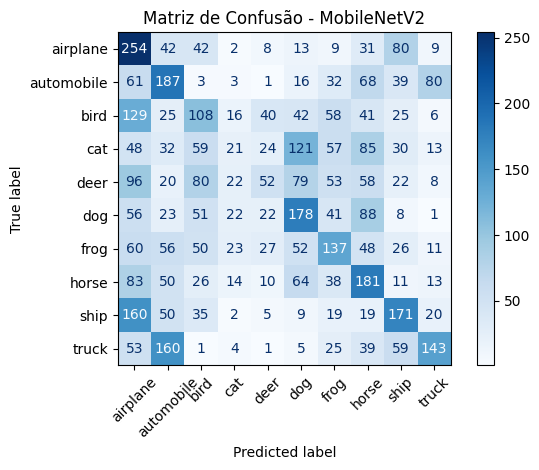

              precision    recall  f1-score   support

    airplane       0.25      0.52      0.34       490
  automobile       0.29      0.38      0.33       490
        bird       0.24      0.22      0.23       490
         cat       0.16      0.04      0.07       490
        deer       0.27      0.11      0.15       490
         dog       0.31      0.36      0.33       490
        frog       0.29      0.28      0.29       490
       horse       0.28      0.37      0.32       490
        ship       0.36      0.35      0.36       490
       truck       0.47      0.29      0.36       490

    accuracy                           0.29      4900
   macro avg       0.29      0.29      0.28      4900
weighted avg       0.29      0.29      0.28      4900

Accuracy score: 0.2922448979591837


In [42]:

ma=confusion_matrix(y, y_pred)

# Visualizar
disp = ConfusionMatrixDisplay(
        confusion_matrix=ma,
        display_labels=category_names
    )

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusão - MobileNetV2")
plt.tight_layout()
plt.show()

# Criando a matriz de confusão
mobile_cm = metrics.confusion_matrix(y, y_pred)
# Definindo a acurácia
mobile_accuracy = metrics.accuracy_score(y, y_pred)

# Print do classification report
print(metrics.classification_report(y, y_pred, target_names=category_names))
# Print da acurácia
print("Accuracy score: {}".format(mobile_accuracy))

In [43]:
# -------------- LIBERA MEMORIA
tf.keras.backend.clear_session()
gc.collect()
del X

### 3) Ajuste fino (Fine Tuning) de uma CNN pré-treinada na base de imagens ImageNet.

In [27]:
from tensorflow.keras.applications.vgg16 import preprocess_input

def prepare_vgg_data(image, label):
    # Redimensiona usando TensorFlow (mais rápido)
    image = tf.image.resize(image, [128, 128])
    # Converte para float32 e normaliza
    image = tf.cast(image, tf.float32)
    # Pré-processamento específico do VGG16 (subtrai médias ImageNet)
    image = preprocess_input(image)
    return image, label

In [28]:
# Diminuindo o tamanho da base para rodar localmente

x_train, _, y_train, _ = train_test_split(
    x_train,
    y_train,
    train_size=5000,
    random_state=rand_seed,
    stratify=y_train
)

In [29]:
trainX, testX, trainY, testY = train_test_split(
    x_train,
    y_train,
    test_size=0.3,
    random_state=rand_seed,
    stratify=y_train
)

trainX, valX, trainY, valY = train_test_split(
    trainX,
    trainY,
    test_size=0.2,
    random_state=rand_seed,
    stratify=trainY
)

In [30]:
train_dataset = tf.data.Dataset.from_tensor_slices((trainX, trainY))
val_dataset = tf.data.Dataset.from_tensor_slices((valX, valY))
test_dataset = tf.data.Dataset.from_tensor_slices((testX, testY))

# Aplica pré-processamento
train_dataset = train_dataset.map(
    prepare_vgg_data,
    num_parallel_calls=tf.data.AUTOTUNE
)
val_dataset = val_dataset.map(
    prepare_vgg_data,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    prepare_vgg_data,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Batch e prefetch
train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)


In [31]:
# Carrega a rede pré-treinada
vgg_conv=VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
# Congelando as camadas carregadas
vgg_conv.trainable = False
   
# Mostrando a topologia da rede carregada
vgg_conv.summary()

# Adaptando a rede para o problema alvo
model = Sequential()
model.add(vgg_conv)
model.add(GlobalMaxPooling2D())  
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

# Compilando o modelo
model.compile(loss=keras.losses.sparse_categorical_crossentropy, 
              optimizer=tf.keras.optimizers.Adam(learning_rate), 
              metrics=['accuracy'])
# Plotando o modelo
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,111,242 (57.64 MB)

 Trainable params: 396,554 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
fp='./vgg16_fineT.weights.h5'
mc=tf.keras.callbacks.ModelCheckpoint(
    filepath=fp,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1)

# Monitor para interromper o modelo antecipadamente quando a melhoria da perda de validação for mínima
monitor_fineT = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1, mode='auto')

# Treinamento do modelo
results_fineT=model.fit(train_dataset,
                  epochs=training_epochs,
                  verbose=2,
                  validation_data=val_dataset,
                  callbacks=[monitor_fineT, mc])

# carregando os pesos do melhor modelo
model.load_weights(fp)

Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.1881 - loss: 2.4609
Epoch 1: val_accuracy improved from -inf to 0.10000, saving model to ./vgg16_fineT.weights.h5
88/88 ━━━━━━━━━━━━━━━━━━━━ 70s 785ms/step - accuracy: 0.1885 - loss: 2.4596 - val_accuracy: 0.1000 - val_loss: 7.8190
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.2798 - loss: 2.0570
Epoch 2: val_accuracy did not improve from 0.10000
88/88 ━━━━━━━━━━━━━━━━━━━━ 70s 802ms/step - accuracy: 0.2798 - loss: 2.0569 - val_accuracy: 0.1000 - val_loss: 5.5883
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.3522 - loss: 1.8896
Epoch 3: val_accuracy did not improve from 0.10000
88/88 ━━━━━━━━━━━━━━━━━━━━ 75s 858ms/step - accuracy: 0.3520 - loss: 1.8898 - val_accuracy: 0.1000 - val_loss: 3.5053
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.3547 - loss: 1.8172
Epoch 4: val_accuracy did not improve from 0.10000
88/88 ━━━━━━━━━━━━━━━━━━━━ 77s 878ms/step - accuracy: 0

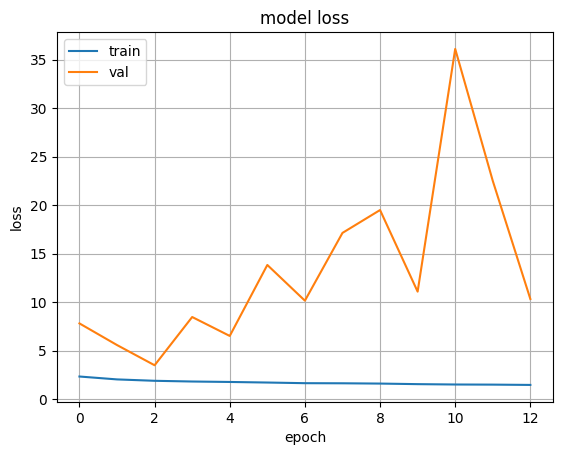

In [33]:
# Validação o erro por épocas
plt.plot(results_fineT.history['loss'])
plt.plot(results_fineT.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

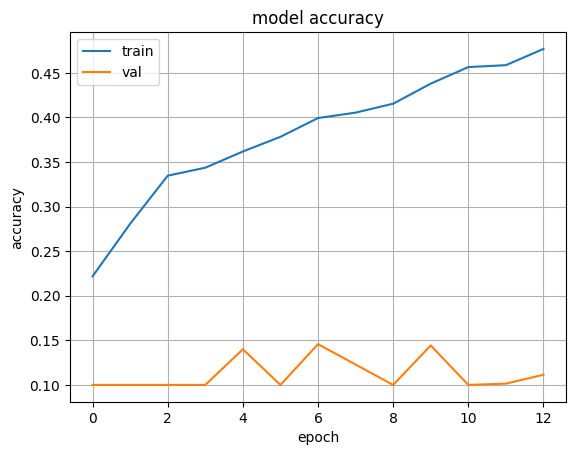

In [34]:
# Validação da acurácia por épocas
plt.plot(results_fineT.history['accuracy'])
plt.plot(results_fineT.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 611ms/step


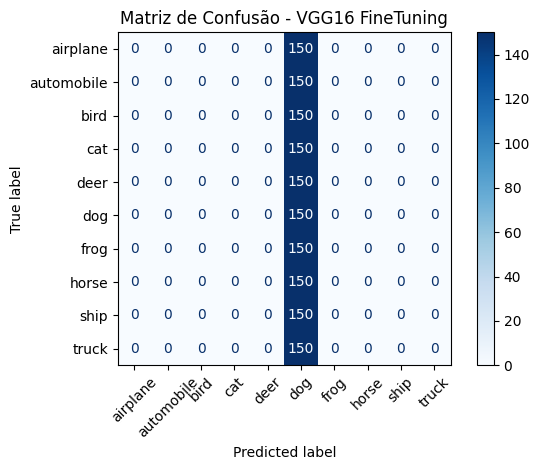

              precision    recall  f1-score   support

    airplane       0.00      0.00      0.00       150
  automobile       0.00      0.00      0.00       150
        bird       0.00      0.00      0.00       150
         cat       0.00      0.00      0.00       150
        deer       0.00      0.00      0.00       150
         dog       0.10      1.00      0.18       150
        frog       0.00      0.00      0.00       150
       horse       0.00      0.00      0.00       150
        ship       0.00      0.00      0.00       150
       truck       0.00      0.00      0.00       150

    accuracy                           0.10      1500
   macro avg       0.01      0.10      0.02      1500
weighted avg       0.01      0.10      0.02      1500

Accuracy score: 0.1


c:\Aurelio\Programacao\Pos Grad\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Aurelio\Programacao\Pos Grad\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Aurelio\Programacao\Pos Grad\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [32]:
# Predição da CNN
y_pred_prob = model.predict(test_dataset)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = testY


# Matriz de confusão
ma = confusion_matrix(y_true,y_pred)

# Visualização
disp = ConfusionMatrixDisplay(
    confusion_matrix=ma,
    display_labels=category_names
)

disp.plot(cmap="Blues",xticks_rotation=45)

plt.title("Matriz de Confusão - VGG16 FineTuning")
plt.tight_layout()
plt.show()

# Métricas
vgg16_fineT_accuracy = metrics.accuracy_score(y_true, y_pred)

print(metrics.classification_report(y_true,y_pred,target_names=category_names))
print("Accuracy score: {}".format(vgg16_fineT_accuracy))

In [33]:
# -------------- LIBERA MEMORIA
tf.keras.backend.clear_session()
gc.collect()

0

### 4) CNN FineTuning DataAugmentation

In [ ]:
# Vetores para armazenar imagens e classes
X = []
y = []


# Leitura das imagens
for imagem, classe in zip(x_train, y_train):
    X.append(imagem)
    y.append(classe)

# Converte listas para numpy
X = np.array(X)
y = np.array(y)

# Salva imagens
np.save('X_dataAug.npy',X)

# Salva classes
df_class = pd.DataFrame(y)

df_class.to_csv(
    'y_dataAug.csv',
    header=False,
    index=False
)

print("Arquivos salvos!")

Arquivos salvos!


In [35]:
y = pd.read_csv('y_dataAug.csv',header=None)

y = y.to_numpy()
y = np.ravel(y)
y = to_categorical(y)
print(y.shape)

# Imagens
X = np.load('X_dataAug.npy')

X = preprocess_input(X)

print(X.shape)


(5000, 10)
(5000, 32, 32, 3)


In [ ]:
vgg_conv = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

vgg_conv.trainable = True

for layer in vgg_conv.layers[:-4]:
    layer.trainable = False
    
vgg_conv.summary()

# Fine Tunning VGG16 (criando a parte totalmente conectada - final da rede)
model = Sequential()
model.add(vgg_conv)
model.add(Flatten())
#model.add(GlobalMaxPooling2D())
model.add(Dense(2048, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1024, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compilar o modelo
model.compile(loss=keras.losses.categorical_crossentropy, optimizer=tf.keras.optimizers.Adam(learning_rate), metrics=['accuracy'] )

model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2048)           │     1,050,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,873,738 (68.18 MB)

 Trainable params: 10,238,474 (39.06 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [41]:
# ModelCheckPoint
fp='./vgg16_dataAug.weights.h5'
mc = tf.keras.callbacks.ModelCheckpoint(

    filepath=fp,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1)

# Monitor para interromper o modelo antecipadamente quando a melhoria da perda de validação for mínima
monitor_dataAug = EarlyStopping(monitor='val_loss', min_delta=1e-5, patience=10, verbose=1, mode='auto')

# Inicialização do gerador de imagens - aplica aleatoriamente distorções
datagen = ImageDataGenerator(
        rotation_range=10,
        zoom_range=0.15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True)

y_labels = np.argmax(y, axis=1)

# Holdout 70/30 (70% para treinar e 30% para testar)
trainX, testX, trainY, testY = train_test_split(X, y, test_size=.3, random_state=rand_seed, stratify=y_labels)

trainY_labels = np.argmax(trainY, axis=1)
# Separando da base de treinamento 20% para validação
trainX, valX, trainY, valY = train_test_split(trainX, trainY, test_size=.2, random_state=rand_seed, stratify=trainY_labels)

# Gerador de lote de imagens aplicando o ImageDataGenerator
train_generator = datagen.flow(trainX, trainY, batch_size=32)

# Treinamento considerando o gerador de iamgens de treino
results_dataAug = model.fit(train_generator, validation_data=(valX, valY),
                    epochs=training_epochs, verbose=2, callbacks=[monitor_dataAug, mc])

# Os pesos do melhor modelo são carregados
model.load_weights(fp)

Epoch 1/20


c:\Aurelio\Programacao\Pos Grad\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.10000, saving model to ./vgg16_dataAug.weights.h5
88/88 - 19s - 219ms/step - accuracy: 0.0961 - loss: 2.3032 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/20

Epoch 2: val_accuracy did not improve from 0.10000
88/88 - 19s - 218ms/step - accuracy: 0.1007 - loss: 2.3031 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/20

Epoch 3: val_accuracy did not improve from 0.10000
88/88 - 19s - 218ms/step - accuracy: 0.0846 - loss: 2.3030 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/20

Epoch 4: val_accuracy did not improve from 0.10000
88/88 - 19s - 216ms/step - accuracy: 0.0811 - loss: 2.3030 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/20

Epoch 5: val_accuracy did not improve from 0.10000
88/88 - 19s - 216ms/step - accuracy: 0.0904 - loss: 2.3031 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 6/20

Epoch 6: val_accuracy did not improve from 0.10000
88/88 - 19s - 218ms/step - accuracy: 0.0943 - loss: 2.3029 - val_accuracy: 0.1000 -

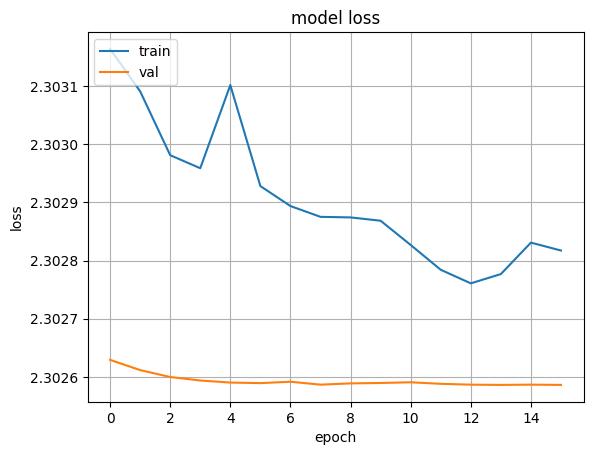

In [42]:
# Validação o erro por épocas
plt.plot(results_dataAug.history['loss'])
plt.plot(results_dataAug.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

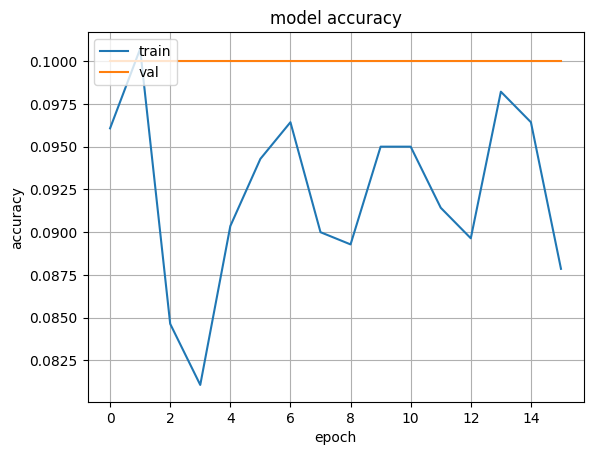

In [43]:
# Validação da acurácia por épocas
plt.plot(results_dataAug.history['accuracy'])
plt.plot(results_dataAug.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step


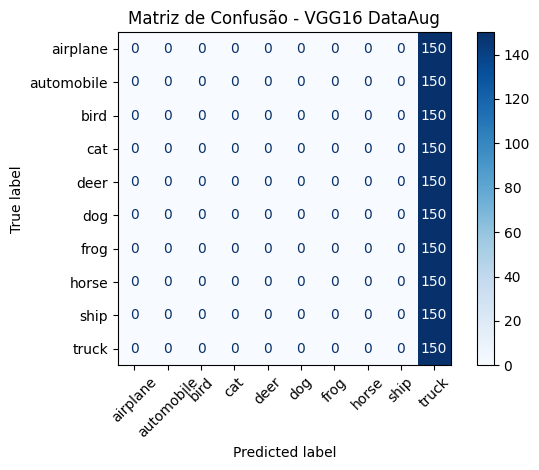

              precision    recall  f1-score   support

    airplane       0.00      0.00      0.00       150
  automobile       0.00      0.00      0.00       150
        bird       0.00      0.00      0.00       150
         cat       0.00      0.00      0.00       150
        deer       0.00      0.00      0.00       150
         dog       0.00      0.00      0.00       150
        frog       0.00      0.00      0.00       150
       horse       0.00      0.00      0.00       150
        ship       0.00      0.00      0.00       150
       truck       0.10      1.00      0.18       150

    accuracy                           0.10      1500
   macro avg       0.01      0.10      0.02      1500
weighted avg       0.01      0.10      0.02      1500

Accuracy score: 0.1


c:\Aurelio\Programacao\Pos Grad\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Aurelio\Programacao\Pos Grad\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Aurelio\Programacao\Pos Grad\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [44]:
# Predição do dataAug
y_pred_prob = model.predict(testX)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(testY, axis=1)

# Matriz de confusão
ma = confusion_matrix(y_true,y_pred)

# Visualização
disp = ConfusionMatrixDisplay(
    confusion_matrix=ma,
    display_labels=category_names
)

disp.plot(cmap="Blues",xticks_rotation=45)

plt.title("Matriz de Confusão - VGG16 DataAug")
plt.tight_layout()
plt.show()

# Métricas
vgg16_dataAug_accuracy = metrics.accuracy_score(y_true, y_pred)

print(metrics.classification_report(y_true,y_pred,target_names=category_names))
print("Accuracy score: {}".format(vgg16_dataAug_accuracy))

In [45]:
# -------------- LIBERA MEMORIA
tf.keras.backend.clear_session()
gc.collect()

0

<!-- ### 5) ajuste fino de um ViT (Visual Transformer) -->

In [ ]:
# W = 224
# H = 224

# num_classes = len(category_names)

# X = X_base.copy()
# y = y_base.copy()


# y_labels = y


# trainX, testX, trainY, testY = train_test_split(
#     X,
#     y,
#     test_size=0.3,
#     random_state=rand_seed,
#     stratify=y_labels
# )

In [ ]:
# def prepare_vit_data(image, label):
#     image = tf.image.resize(image, (224,224))
#     image = tf.cast(image, tf.float32)

#     # ViT espera valores entre 0 e 1
#     image = image / 255.0

#     return image, label

In [ ]:
# train_dataset = tf.data.Dataset.from_tensor_slices(
#     (trainX, trainY)
# )

# test_dataset = tf.data.Dataset.from_tensor_slices(
#     (testX, testY)
# )


# train_dataset = train_dataset.map(
#     prepare_vit_data,
#     num_parallel_calls=tf.data.AUTOTUNE
# )

# test_dataset = test_dataset.map(
#     prepare_vit_data,
#     num_parallel_calls=tf.data.AUTOTUNE
# )


# train_dataset = train_dataset.batch(16).prefetch(tf.data.AUTOTUNE)

# test_dataset = test_dataset.batch(16).prefetch(tf.data.AUTOTUNE)

In [ ]:
# vit_url = "https://tfhub.dev/sayakpaul/vit_s16_fe/1"
# vit_layer = hub.KerasLayer(vit_url, trainable=True)

# class ViTModel(tf.keras.Model):
#     def __init__(self, vit_layer, num_classes):
#         super(ViTModel, self).__init__()
#         self.vit = vit_layer
#         self.dense1 = tf.keras.layers.Dense(128, activation='relu')
#         self.dropout = tf.keras.layers.Dropout(0.3)
#         self.classifier = tf.keras.layers.Dense(num_classes, activation='softmax')

#     def call(self, inputs):
#         x = inputs
#         vit_outputs = self.vit(x)
# #        x = vit_outputs['pooled_output']
#         x = vit_outputs
#         x = self.dense1(x)
#         x = self.dropout(x)
#         return self.classifier(x)



In [ ]:
# # instanciar modelo
# model = ViTModel(vit_layer, num_classes)

# mc_vit = tf.keras.callbacks.ModelCheckpoint(
#     filepath="./vit_best.weights.h5",
#     save_weights_only=True,
#     monitor="val_accuracy",
#     mode="max",
#     save_best_only=True,
#     verbose=1
# )

# # Monitor para interromper o modelo antecipadamente quando a melhoria da perda de validação for mínima
# monitor_vit = EarlyStopping(monitor='val_loss', restore_best_weights=True, patience=3, verbose=1, mode='auto')

# ## 6. Compilar e treinar
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate = 1e-5),
#     loss='sparse_categorical_crossentropy',
#     metrics=['accuracy']
# )

# history_vit = model.fit(
#     train_dataset,
#     epochs=training_epochs,
#     validation_data=test_dataset,
#     callbacks=[monitor_vit, mc_vit]
# )

# model.load_weights("./vit_best.weights.h5")

Epoch 1/20
106/438 ━━━━━━━━━━━━━━━━━━━━ 3:29 631ms/step - accuracy: 0.0802 - loss: 2.8435

KeyboardInterrupt: 

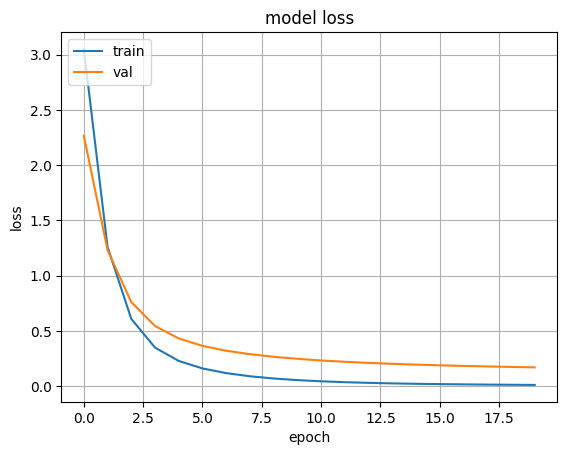

In [ ]:
# Validação o erro por épocas
plt.plot(history_vit.history['loss'])
plt.plot(history_vit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

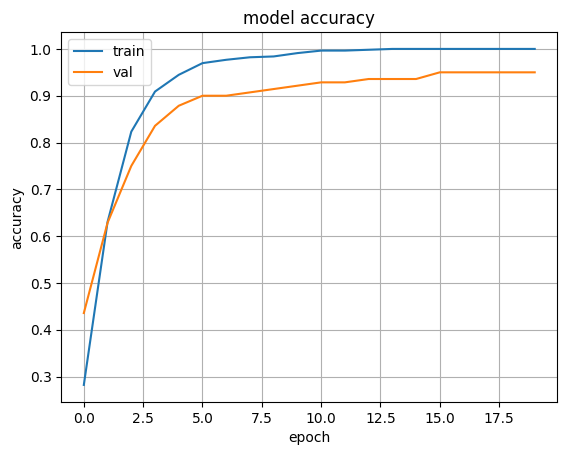

In [ ]:
# Validação da acurácia por épocas
plt.plot(history_vit.history['accuracy'])
plt.plot(history_vit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step


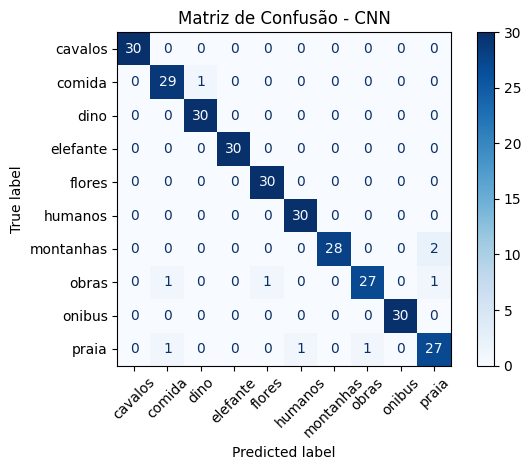

              precision    recall  f1-score   support

     cavalos       1.00      1.00      1.00        30
      comida       0.94      0.97      0.95        30
        dino       0.97      1.00      0.98        30
    elefante       1.00      1.00      1.00        30
      flores       0.97      1.00      0.98        30
     humanos       0.97      1.00      0.98        30
   montanhas       1.00      0.93      0.97        30
       obras       0.96      0.90      0.93        30
      onibus       1.00      1.00      1.00        30
       praia       0.90      0.90      0.90        30

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300

Accuracy score: 0.97


In [ ]:
# Predição do VIT
y_pred_prob = model.predict(testX)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(testY, axis=1)

# Matriz de confusão
ma = confusion_matrix(y_true,y_pred)

# Visualização
disp = ConfusionMatrixDisplay(
    confusion_matrix=ma,
    display_labels=category_names
)

disp.plot(cmap="Blues",xticks_rotation=45)

plt.title("Matriz de Confusão - ViT FineT")
plt.tight_layout()
plt.show()

# Métricas
vit_accuracy = metrics.accuracy_score(y_true, y_pred)

print(metrics.classification_report(y_true,y_pred,target_names=category_names))
print("Accuracy score: {}".format(vit_accuracy))